# Ejemplo de ejecucion del modelo 2D
Este ejemplo corre una simulacion corta y muestra un snapshot final y la cobertura total.

0.0
0.8158214956594422
1.12036975966121
1.2782589754585216
1.5497469365622043
1.750067908970935
1.8951149184672467
2.0691257436907784
2.2212412239792854
2.3409166498664518
2.4300659277820587
2.517700885601773
2.6045278385036448
2.6898079089745144
2.7887271022655082
2.878296916812642
2.9334302476638423
3.008463376437656
3.0794632740783943
3.1338749802890864
3.2094666317912233
3.2743689366951227
3.335015494403393
3.4195857388001736
3.4792457506289365
3.5386805420541956
3.61566100022149
3.680425573161254
3.7668716714942696
3.845076734275824
3.923449747046957
3.9906574500031593
4.0697494017929765
4.152566820528061
4.232141513111428
4.335899152543267
4.413306487760723
4.522991024523136
4.6243498251653525
4.7544866946455056
4.961451080443927


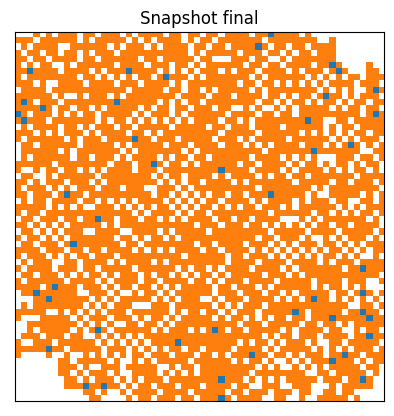

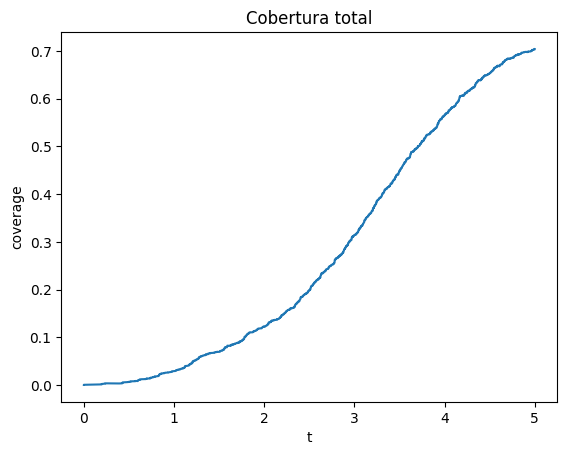

In [3]:
# Configuracion de rutas para importar el paquete del proyecto
import sys
from pathlib import Path

# Dependencias permitidas
import numpy as np
import matplotlib.pyplot as plt

# Agregar la raiz del proyecto al path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

sys.path.append(r'c:/Users/sebas/MalariaProject/src')

# Importar el modelo 2D
from src.model2D import Params2D, KMC2D, KMC2DVisualizer

# Ejecutar una simulacion corta
params = Params2D(Ead = 0.25, Ede = 0.2, Eai = 0.2, Eab = 0.1, Eac = 0.1,
                  Jad = 0.04, Jinc = 0.2, Jdes = 0.05, Jmove= 0.03, mu = -0.10)
kmc = KMC2D(params, seed=0)
times, cover, snapshots = kmc.run_until(tmax=5.0, store_snapshots=True)

# Visualizar un snapshot final
viz = KMC2DVisualizer()
viz.plot_snapshot(snapshots[-1], title="Snapshot final")

# Graficar la cobertura total en el tiempo
plt.figure()
plt.plot(times, cover)
plt.xlabel("t")
plt.ylabel("coverage")
plt.title("Cobertura total")
plt.show()

GIF guardado en: c:\Users\sebas\MalariaProject\results\model2d.gif


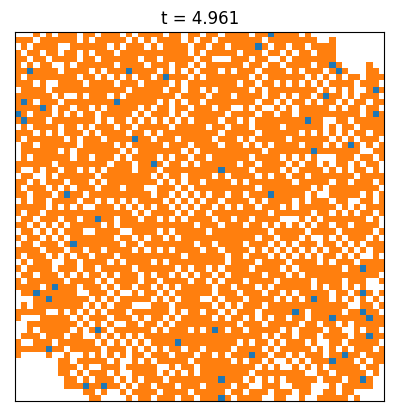

In [4]:
# Guardar un GIF de la simulacion completa
# Nota: matplotlib usa PillowWriter; si Pillow no esta instalado se mostrara un error claro.
out_dir = project_root / "results"
out_dir.mkdir(parents=True, exist_ok=True)
gif_path = out_dir / "model2d.gif"

try:
    viz.save_gif(snapshots, str(gif_path), fps=8)
    print(f"GIF guardado en: {gif_path}")
except RuntimeError as exc:
    print("No se pudo guardar el GIF. Para habilitarlo, instala Pillow.")
    print(exc)

0.0
0.5366674460279038
0.7724674298584033
1.0125942813888649
1.1898161407648435
1.4272396630069915
1.6054871959261658
1.8912368186464406
2.1449342663144035
2.336446644430765
2.7392725109619196
3.092372346273028
3.312850303799365
3.543294463158868
3.83151661438907
4.088325743784504
4.343097271453097
4.511204387876315
4.630500485633097
4.688478799413776
4.808901445569735
4.957468140573275


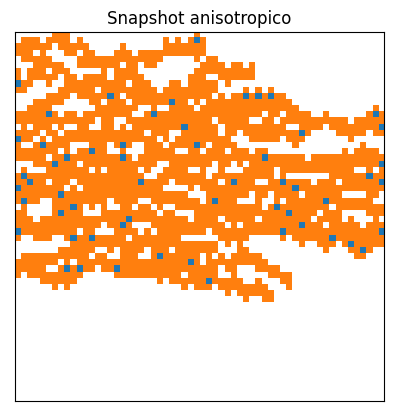

Aspect ratio (dx/dy) = 0.73 (dx=44, dy=60)


In [30]:
# Prueba de anisotropia de forma usando el modelo 2D v2
from src.model2D_v2 import Params2D as Params2D_v2, KMC2D as KMC2D_v2, KMC2DVisualizer as KMC2DVisualizer_v2

# Parametros con sesgo direccional (x != y) para forzar anisotropia
# params_aniso = Params2D_v2(
#     Ead=0.25,
#     Ede=0.2,
#     Eai=0.2,
#     Eab=0.1,
#     Eac=0.1,
#     Jad_x=0.02,
#     Jad_y=0.08,
#     Jinc_x=0.05,
#     Jinc_y=0.15,
#     Jdes_x=0.03,
#     Jdes_y=0.07,
#     Jmove_x=0.02,
#     Jmove_y=0.06,
#     mu=-0.10,
#  )

params_aniso = Params2D_v2(
    Ead=0.25, Ede=0.2, Eai=0.2, Eab=0.1, Eac=0.1,
    Jad_x=0.12, Jad_y=0.01,
    Jinc_x=0.30, Jinc_y=0.02,
    Jdes_x=0.20, Jdes_y=0.02,
    Jmove_x=0.12, Jmove_y=0.01,
    mu=-0.10,
)

kmc_aniso = KMC2D_v2(params_aniso, seed=0)
times_a, cover_a, snapshots_a = kmc_aniso.run_until(tmax=5.0, store_snapshots=True)

# Visualizar un snapshot final anisotropico
viz_a = KMC2DVisualizer_v2()
viz_a.plot_snapshot(snapshots_a[-1], title="Snapshot anisotropico")

# Medida simple de anisotropia: aspecto del bounding box de ocupacion
grid_final = snapshots_a[-1][1]
occupied = np.argwhere(grid_final > 0)
if occupied.size > 0:
    x_min, y_min = occupied.min(axis=0)
    x_max, y_max = occupied.max(axis=0)
    dx = x_max - x_min + 1
    dy = y_max - y_min + 1
    aspect = dx / dy if dy > 0 else np.nan
    print(f"Aspect ratio (dx/dy) = {aspect:.2f} (dx={dx}, dy={dy})")
else:
    print("No hay sitios ocupados para medir anisotropia.")

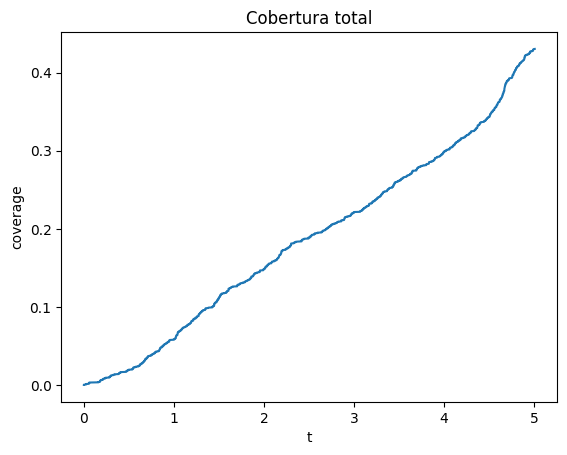

In [32]:
# Graficar la cobertura total en el tiempo
plt.figure()
plt.plot(times_a, cover_a)
plt.xlabel("t")
plt.ylabel("coverage")
plt.title("Cobertura total")
plt.show()

GIF guardado en: c:\Users\sebas\MalariaProject\results\model2d_a.gif


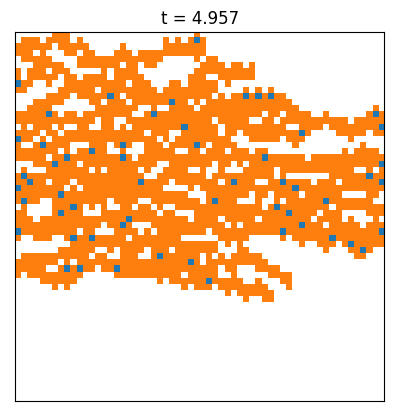

In [31]:
# Guardar un GIF de la simulacion completa
# Nota: matplotlib usa PillowWriter; si Pillow no esta instalado se mostrara un error claro.
out_dir = project_root / "results"
out_dir.mkdir(parents=True, exist_ok=True)
gif_path = out_dir / "model2d_a.gif"

try:
    viz_a.save_gif(snapshots_a, str(gif_path), fps=8)
    print(f"GIF guardado en: {gif_path}")
except RuntimeError as exc:
    print("No se pudo guardar el GIF. Para habilitarlo, instala Pillow.")
    print(exc)

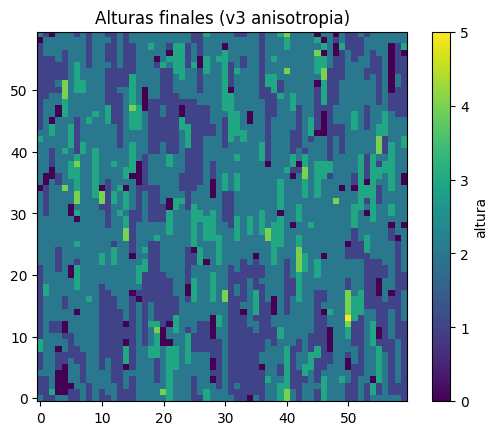

Aspect ratio (dx/dy) = 1.00 (dx=60, dy=60)


In [25]:
# Prueba de anisotropia de forma en el SOS 3D (v3)
import numpy as np
import matplotlib.pyplot as plt
from src.params_v3 import KMCParams_v3
from src.lattice_v3 import LatticeSOS_v3
from src.bkl_v3 import KMC_BKL_v3


# Inicializar la red con semillas para arrancar el crecimiento
lat3 = LatticeSOS_v3(size=60, seed=0)
lat3.initialize(mode="seeds", n_seeds=80)

# Parametros con anisotropia direccional (x != y)
params3 = KMCParams_v3(
    K0_plus=0.2,
    E_pb_over_kT_x=2.0,
    E_pb_over_kT_y=0.2,
    phi_over_kT=3.2,
    delta_x=1.2,
    delta_y=0.1,
    V=1.0,
    C_eq=15.0,
    fixed_sigma=0.5,
)
kmc3 = KMC_BKL_v3(lat3, params3, N_bulk0=1000, rng_seed=0, constant_concentration=True)
snaps3, stats3 = kmc3.run(t_end=1.5, snapshot_times=[0.5, 1.0, 1.5])

# Visualizar alturas finales
heights3 = snaps3[-1][1]
plt.figure()
plt.imshow(heights3, origin="lower")
plt.colorbar(label="altura")
plt.title("Alturas finales (v3 anisotropia)")
plt.show()

# Medida simple de anisotropia: aspecto del soporte ocupado
occupied3 = np.argwhere(heights3 > 0)
if occupied3.size > 0:
    x_min3, y_min3 = occupied3.min(axis=0)
    x_max3, y_max3 = occupied3.max(axis=0)
    dx3 = x_max3 - x_min3 + 1
    dy3 = y_max3 - y_min3 + 1
    aspect3 = dx3 / dy3 if dy3 > 0 else np.nan
    print(f"Aspect ratio (dx/dy) = {aspect3:.2f} (dx={dx3}, dy={dy3})")
else:
    print("No hay sitios ocupados para medir anisotropia.")

In [26]:
from src.plotter_v2 import Plotter_v2
plotter = Plotter_v2(kmc3)

🧩 Snapshot seleccionado: t=1.500


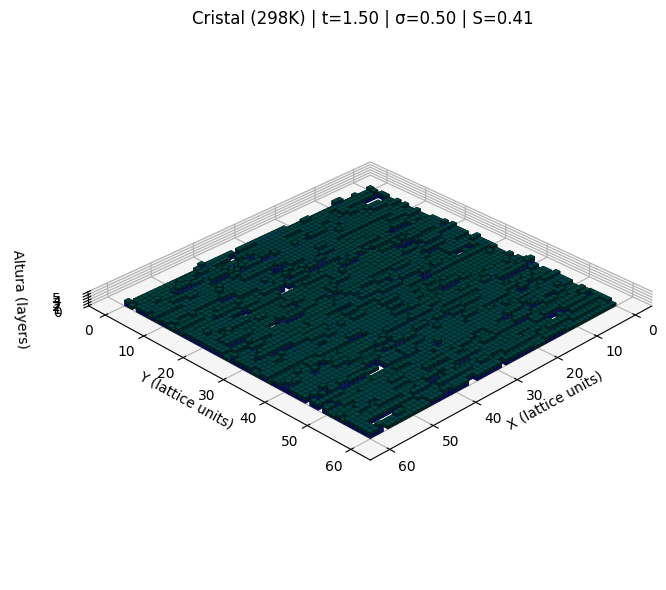

In [27]:
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps3,
    t_snapshot=times[len(times)- 1],
)

In [28]:
plotter.crystal_growth_gif(
    snapshots=snaps3,
    save_path="crystal_growth_ani.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento kMC SOS",
    every_n=1,
)

💾 GIF guardado en: crystal_growth_ani.gif
